<a href="https://colab.research.google.com/github/Rhuthvija/calmin30-webapp/blob/main/FocusIQ_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



<div style="background: linear-gradient(135deg, #0d0d0d, #1a1a2e, #16213e);
            padding: 36px; border-radius: 16px; text-align: center; font-family: Georgia, serif;">

  <h1 style="color: #f0e6d3; font-size: 36px; margin: 0; letter-spacing: 2px;">
    🎯 FocusIQ
  </h1>

  <p style="color: #cfcfcf; font-size: 15px; margin: 12px 0 6px 0;">
    Why do we lose focus even when we want to study?
  </p>

  <p style="color: #a0c4ff; font-size: 14px; margin: 0;">
    FocusIQ analyzes your daily habits to predict your focus level,
    procrastination risk, and help you study more effectively.
  </p>

</div>

<div style="margin-top:18px; font-family:'Segoe UI',sans-serif; max-width:700px; color:#e0e0e0;">

<p style="font-size:14px;">
This system takes simple inputs like sleep, stress, phone usage, and motivation,
and gives you clear insights into how well you can focus and what might distract you.
</p>

<ul style="line-height:1.8; font-size:14px;">
  <li>🎯 Focus Score</li>
  <li>⚠️ Procrastination Risk</li>
  <li>💡 Personalized Suggestions</li>
</ul>

</div>


---
## 📦 Part 1 — Setup & Libraries

In [7]:
# ─────────────────────────────────────────────────────────────────
#  CELL 1 — Install & Import
# ─────────────────────────────────────────────────────────────────
!pip install ipywidgets --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.cluster        import KMeans
from sklearn.svm            import SVC
from sklearn.linear_model   import LinearRegression
from sklearn.ensemble       import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.metrics        import (
    mean_squared_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)

# Widgets
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ All libraries loaded!')

✅ All libraries loaded!


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 📊 Part 2 — Dataset Generation
We simulate **1,500 student records** using realistic correlations backed by educational psychology research.  
Features are limited to **7 inputs** — only what a student can easily and accurately report about themselves.

In [9]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/student-mat.csv")

# --- DIAGNOSTIC: Print columns to verify ---
print("Columns in DataFrame after loading CSV:", df.columns.tolist())
# --------------------------------------------

# Basic feature mapping
df.rename(columns={
    'studytime': 'study_hours',
    'health': 'stress_level'
}, inplace=True)

df['study_hours'] = df['study_hours'] * 2.5

# Minimal feature engineering
np.random.seed(42)

df['sleep_hours'] = np.clip(np.random.normal(6.5, 1.5, len(df)), 3, 10)
df['phone_usage_hrs'] = np.clip(np.random.normal(4.0, 2.0, len(df)), 0, 10)
df['task_difficulty'] = np.clip(np.random.normal(5.0, 2.0, len(df)), 1, 10) # Added missing column

df['motivation_level'] = df['study_hours'].clip(1, 10)
df['exercise_done'] = (df['absences'] < df['absences'].median()).astype(int)

# Target variables
focus_raw = (
    8 * df['study_hours']
    + 5 * df['sleep_hours']
    + 5 * df['motivation_level']
    - 5 * df['stress_level']
    - 4 * df['phone_usage_hrs']
    - 2 * df['task_difficulty'] # Also add task_difficulty to focus_raw calculation
)

df['focus_score'] = (
    100 * (focus_raw - focus_raw.min()) / (focus_raw.max() - focus_raw.min())
)

proc_raw = (
    0.4 * df['phone_usage_hrs']
    + 0.3 * df['stress_level']
    - 0.3 * df['motivation_level']
)

df['procrastination_risk'] = pd.cut(
    proc_raw,
    bins=[-np.inf, 1.5, 3, np.inf],
    labels=['Low', 'Medium', 'High']
)


Columns in DataFrame after loading CSV: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


---
## 🔍 Part 3 — Exploratory Data Analysis (EDA)

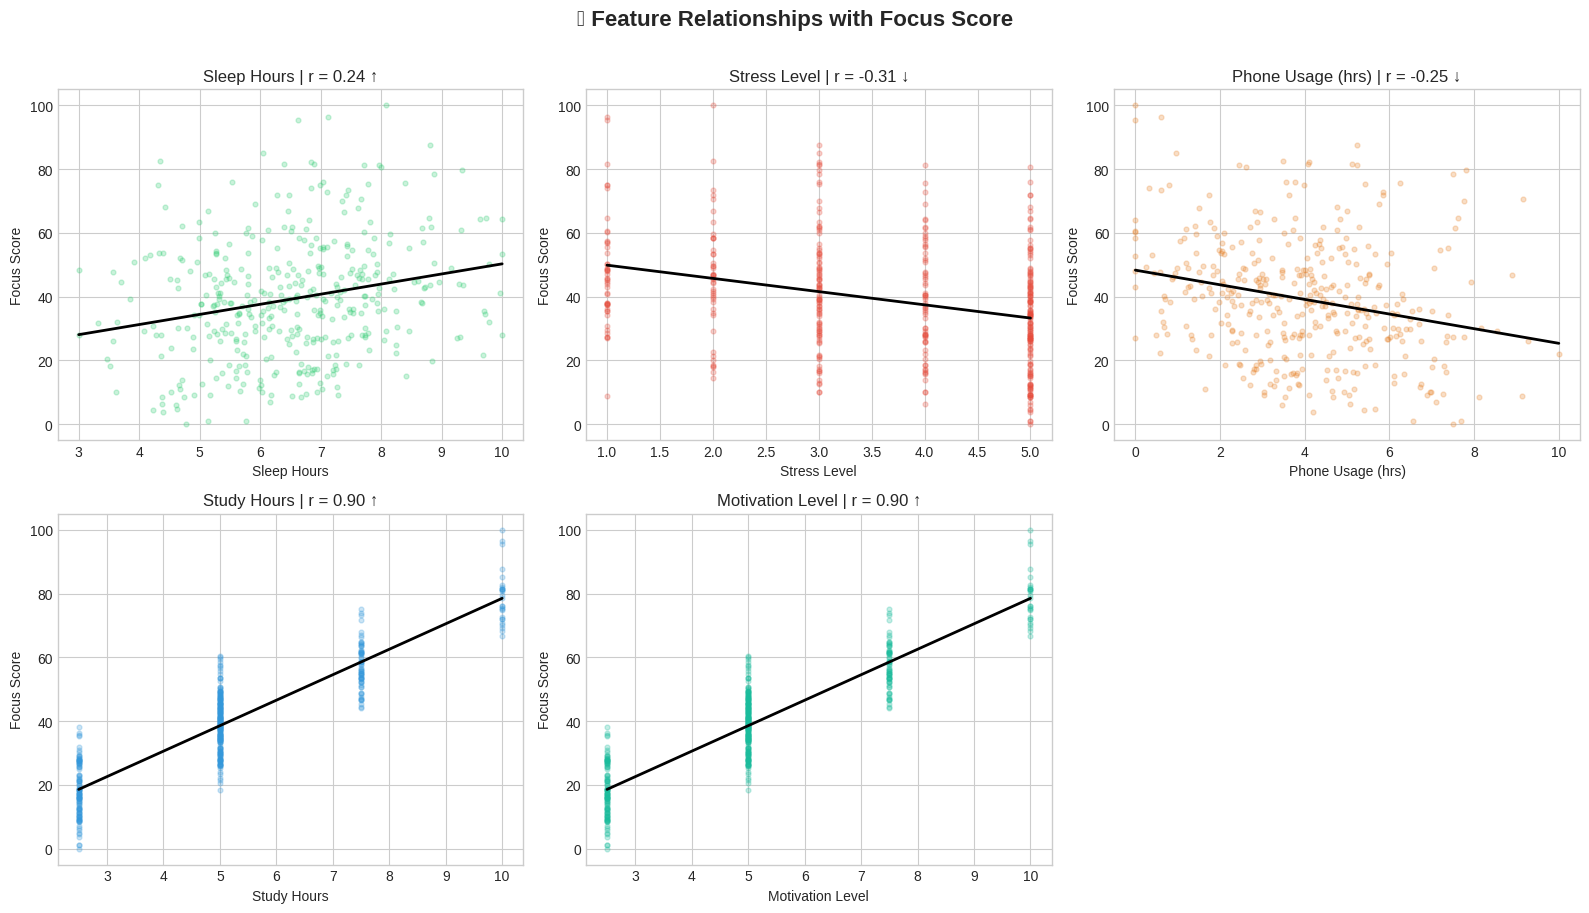

In [10]:
# ─────────────────────────────────────────────────────────────────
#  CELL 3 — Feature vs Focus Scatter Plots (Fixed)
# ─────────────────────────────────────────────────────────────────

feature_cols = ['sleep_hours','stress_level','phone_usage_hrs',
                'study_hours','motivation_level']

feature_labels = ['Sleep Hours','Stress Level','Phone Usage (hrs)',
                  'Study Hours','Motivation Level']

colors = ['#2ecc71','#e74c3c','#e67e22','#3498db','#1abc9c']


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('📊 Feature Relationships with Focus Score', fontsize=16, fontweight='bold', y=1.01)

for ax, feat, label, col in zip(axes.flat, feature_cols, feature_labels, colors):
    ax.scatter(df[feat], df['focus_score'], alpha=0.25, color=col, s=12)

    m, b = np.polyfit(df[feat], df['focus_score'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, 'k-', linewidth=2)

    corr = df[feat].corr(df['focus_score'])
    direction = '↑' if corr > 0 else '↓'

    ax.set_xlabel(label)
    ax.set_ylabel('Focus Score')
    ax.set_title(f'{label} | r = {corr:.2f} {direction}')

# Remove extra empty plot (since now only 5 features)
fig.delaxes(axes[1][2])

plt.tight_layout()
plt.show()

---
## ⚙️ Part 4 — Data Preparation

In [11]:
# ─────────────────────────────────────────────────────────────────
#  CELL 4 — Train/Test Split & Scaling (Simplified)
# ─────────────────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

FEATURES = ['sleep_hours','stress_level','phone_usage_hrs',
            'study_hours','motivation_level','exercise_done']

X = df[FEATURES].values
y_focus = df['focus_score'].values
y_risk  = LabelEncoder().fit_transform(df['procrastination_risk'])

# Split
X_tr, X_te, yF_tr, yF_te = train_test_split(X, y_focus, test_size=0.2, random_state=42)
_,    _,    yP_tr, yP_te = train_test_split(X, y_risk,  test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

print("✅ Data ready for training")

✅ Data ready for training


---
## 🤖 Part 5 — Model Training & Evaluation

### 5A · K-Means Clustering — Student Behavior Archetypes

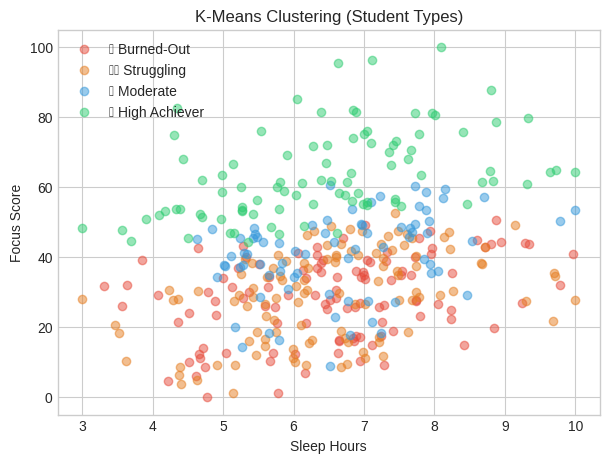


📊 Average Focus Score per Archetype:
archetype
⚠️ Struggling      29.20
📚 Moderate         40.79
😴 Burned-Out       28.52
🚀 High Achiever    63.66
Name: focus_score, dtype: float64


In [12]:
# ─────────────────────────────────────────────────────────────────
#  CELL 5A — K-Means (Simple + 1 Plot)
# ─────────────────────────────────────────────────────────────────

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Train model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaler.transform(X)) # Corrected: Apply to the full dataset X after scaling

# Label clusters
cluster_avg = df.groupby('cluster')['focus_score'].mean().sort_values()

labels = ['😴 Burned-Out','⚠️ Struggling','📚 Moderate','🚀 High Achiever']
archetype_map = {cid: labels[i] for i, cid in enumerate(cluster_avg.index)}
df['archetype'] = df['cluster'].map(archetype_map)

# ── SIMPLE PLOT (keep only this)
colors = ['#e74c3c','#e67e22','#3498db','#2ecc71']

plt.figure(figsize=(7,5))

for i, (cid, name) in enumerate(archetype_map.items()):
    mask = df['cluster'] == cid
    plt.scatter(df.loc[mask, 'sleep_hours'],
                df.loc[mask, 'focus_score'],
                color=colors[i], label=name, alpha=0.5)

plt.xlabel("Sleep Hours")
plt.ylabel("Focus Score")
plt.title("K-Means Clustering (Student Types)")
plt.legend()
plt.show()

print("\n📊 Average Focus Score per Archetype:")
print(df.groupby('archetype')['focus_score'].mean().round(2))

### 5B · Random Forest — Advanced Focus Score Predictor

✅ Random Forest R² Score: 0.971


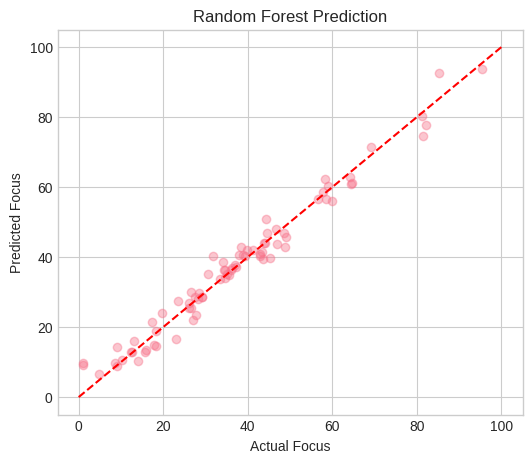

In [13]:
# ─────────────────────────────────────────────────────────────────
#  CELL 5C — Random Forest (Simplified)
# ─────────────────────────────────────────────────────────────────

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Train model
rf_focus = RandomForestRegressor(n_estimators=100, random_state=42)
rf_focus.fit(X_tr_sc, yF_tr)

# Predictions
yF_pred = rf_focus.predict(X_te_sc)

# Evaluation
rf_r2 = r2_score(yF_te, yF_pred)

print(f"✅ Random Forest R² Score: {rf_r2:.3f}")


# ── Simple Plot (Actual vs Predicted)
plt.figure(figsize=(6,5))
plt.scatter(yF_te, yF_pred, alpha=0.4)
plt.plot([0,100], [0,100], 'r--')

plt.xlabel("Actual Focus")
plt.ylabel("Predicted Focus")
plt.title("Random Forest Prediction")

plt.show()

### 5C · SVM — Procrastination Risk Classifier

✅ SVM Accuracy: 0.924


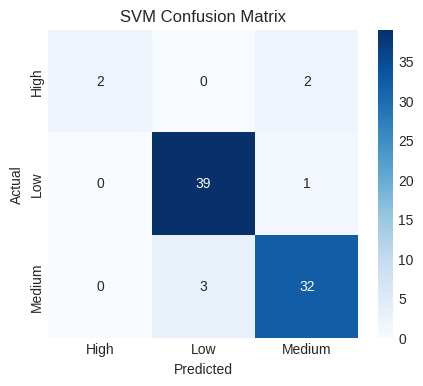

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

# Initialize and fit LabelEncoder if not already defined (to get classes for plotting)
# This assumes df and 'procrastination_risk' are available from previous cells
if 'le' not in locals() and 'le' not in globals():
    le = LabelEncoder()
    le.fit(df['procrastination_risk'])

# Train model
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_tr_sc, yP_tr)

# Predictions
yP_pred = svm.predict(X_te_sc)

# Accuracy
svm_acc = accuracy_score(yP_te, yP_pred)
print(f"✅ SVM Accuracy: {svm_acc:.3f}")


# ── Simple Confusion Matrix Plot
cm = confusion_matrix(yP_te, yP_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

---
## 🎛️ Part 6 — Interactive Prediction Dashboard

> **Adjust the 7 sliders and press Predict — the system tells you everything.**

In [15]:
# ─────────────────────────────────────────────────────────────────
#  CELL 6 — Interactive Dashboard (FINAL CLEAN VERSION)
# ─────────────────────────────────────────────────────────────────

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np

# ── Suggestion Engine ────────────────────────────────────────────
def get_suggestions(sleep, stress, phone, study, motivation, exercise,
                    focus, risk_label):

    tips = []

    if sleep < 6:
        tips.append('💤 Sleep is low. Try to get 7–8 hrs.')

    if stress >= 7:
        tips.append('😰 High stress. Take a short break.')

    if phone >= 5:
        tips.append('📱 Too much phone usage. Reduce distractions.')

    if motivation < 4:
        tips.append('🎯 Low motivation. Start with a small task.')

    if study < 1:
        tips.append('📖 Try at least one focused study session.')

    if exercise == 0:
        tips.append('🏃 Add some physical activity.')

    if risk_label == 'High':
        tips.append('🚨 High procrastination risk! Start immediately.')

    # 🔥 NEW LOGIC (IMPORTANT)
    if not tips:
        if focus < 40:
            tips.append('⚠️ Your focus is low. Try improving sleep and reducing distractions.')
        elif focus < 70:
            tips.append('🙂 Decent focus, but there is room to improve.')
        else:
            tips.append('✅ You are in a good state. Stay consistent!')

    return tips
# ── Widgets ─────────────────────────────────────────────────────
S  = {'description_width': '170px'}
L  = widgets.Layout(width='480px')

w_sleep  = widgets.FloatSlider(value=6.5, min=3, max=10, step=0.5,
                                description='😴 Sleep (hrs):', style=S, layout=L)

w_stress = widgets.FloatSlider(value=5, min=1, max=10, step=0.5,
                                description='😰 Stress Level:', style=S, layout=L)

w_phone  = widgets.FloatSlider(value=3, min=0, max=12, step=0.5,
                                description='📱 Phone Usage (hrs):', style=S, layout=L)

w_study  = widgets.FloatSlider(value=3, min=0, max=10, step=0.5,
                                description='⏳ Study Hours:', style=S, layout=L)

w_motiv  = widgets.FloatSlider(value=6, min=1, max=10, step=0.5,
                                description='🔥 Motivation:', style=S, layout=L)

w_exer   = widgets.ToggleButton(
    value=False,
    description='🏃 Exercise: NO',
    button_style='warning'
)

def toggle_exercise(change):
    if change['new']:
        w_exer.description = '🏃 Exercise: YES'
        w_exer.button_style = 'success'
    else:
        w_exer.description = '🏃 Exercise: NO'
        w_exer.button_style = 'warning'

w_exer.observe(toggle_exercise, names='value')


btn = widgets.Button(description='🔮 Predict My Focus', button_style='primary')
out = widgets.Output()


# ── Prediction Logic ─────────────────────────────────────────────
def on_predict(b):
    with out:
        clear_output()

        vals = np.array([[
            w_sleep.value,
            w_stress.value,
            w_phone.value,
            w_study.value,
            w_motiv.value,
            float(w_exer.value)
        ]])

        vals_sc = scaler.transform(vals)

        focus_pred = float(np.clip(rf_focus.predict(vals_sc)[0], 0, 100))
        risk_label = le.inverse_transform([svm.predict(vals_sc)[0]])[0]

        tips = get_suggestions(
            w_sleep.value, w_stress.value, w_phone.value,
            w_study.value, w_motiv.value,
            float(w_exer.value), focus_pred, risk_label
        )

        tips_html = ''.join([
            f"<div style='padding:8px; margin:5px 0; background:#eef5ff; "
            f"border-left:4px solid #3498db; color:#1a1a1a; font-size:14px;'> {t} </div>"
            for t in tips
        ])

        html = f"""
        <div style="font-family:Segoe UI; max-width:700px;">

          <div style="background:#1a1a2e; color:white; padding:18px; border-radius:10px 10px 0 0;">
            <h2 style="margin:0;">🎯 FocusIQ — Results</h2>
          </div>

          <div style="display:flex; background:#f4f4f8; border:1px solid #ddd; border-top:none;">

            <div style="flex:1; padding:20px; text-align:center;">
              <div style="font-size:40px; font-weight:bold; color:black;">{focus_pred:.0f}</div>
              <div style="color:#333;">Focus Score</div>
            </div>

            <div style="flex:1; padding:20px; text-align:center;">
              <div style="font-size:24px; font-weight:bold; color:black;">{risk_label}</div>
              <div style="color:#333;">Procrastination Risk</div>
            </div>

          </div>

          <div style="background:white; border:1px solid #ddd; border-top:none; padding:15px; border-radius:0 0 10px 10px;">
            <h4 style="color:black;">💡 Suggestions</h4>
            {tips_html}
          </div>

        </div>
        """

        display(HTML(html))


btn.on_click(on_predict)


# ── Layout ──────────────────────────────────────────────────────
display(HTML("<h2 style='color:black;'>🎛️ FocusIQ Dashboard</h2>"))

display(widgets.VBox([
    w_sleep, w_stress, w_phone,
    w_study, w_motiv,
    w_exer, btn, out
]))


# ── Conclusion ──────────────────────────────────────────────────
display(HTML("""
<hr>
<h3 style='color:white;'>📌 Conclusion</h3>
<p style='color:#e0e0e0;'>
This system helps students understand their focus levels and predict procrastination risk
using simple inputs like sleep, stress, and phone usage.
</p>
"""))